# Cⁿ Smooth Goode Homolopolynomial Projection

*The classical Goode homolosine projection has a visible kink at latitude 40.736662°, because the sinusoidal and Mollweide regions are joined only with C0 continuity.

By inserting a Strebe's equal-area polynomial projection transition region between the two projections, a Cn-smooth Goode Homolopolynomial variant can be constructed.*

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import geopandas as gpd
from scipy.interpolate import PchipInterpolator
from scipy.integrate import cumulative_trapezoid
from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString, GeometryCollection

# -----------------------------
# Mollweide functions: 그대로 유지
# -----------------------------

def theta_from_phi(phi_arr):
    phi_arr = np.asarray(phi_arr, dtype=float)
    theta = phi_arr / 2
    for _ in range(80):
        f = 2*theta + np.sin(2*theta) - np.pi*np.sin(phi_arr)
        fp = 2 + 2*np.cos(2*theta)
        theta = np.where(np.abs(fp) > 1e-12, theta - f/fp, theta)
    return theta

def p_moll(phi):
    th = theta_from_phi(phi)
    return np.pi * np.cos(phi) / (2*np.sqrt(2)*np.cos(th))

def p_spacing(phi):
    phi_arr = np.asarray(phi, dtype=float)
    scalar = phi_arr.ndim == 0
    phi_arr = np.atleast_1d(phi_arr)

    u = np.abs(phi_arr)
    out = np.empty_like(phi_arr, dtype=float)

    mask_low = u <= phi1
    mask_mid = (u > phi1) & (u <= phi2)
    mask_high = u > phi2

    out[mask_low] = 1.0

    t = u[mask_mid] - phi1
    p_transition = np.ones_like(t)

    if a is not None:
        p_transition -= a * t**2
    if b is not None:
        p_transition -= b * t**3
    if c is not None:
        p_transition -= c * t**4

    out[mask_mid] = p_transition

    if np.any(mask_high):
        out[mask_high] = [float(p_moll(float(x))) for x in phi_arr[mask_high]]

    return float(out[0]) if scalar else out
# -----------------------------
# Projection factory
# -----------------------------

def make_projection(phi1_deg, phi2_deg, a=None,b=None, c=None, n_grid=40000):
    """
    p(t)=1-a*t^3+c*t^4 지원.
    c=None이면 p(t)=1-a*t^3.
    """

    phi1 = np.deg2rad(phi1_deg)
    phi2 = np.deg2rad(phi2_deg)

    def p_spacing(phi):
        phi = np.asarray(phi, dtype=float)
        u = np.abs(phi)
        t = u - phi1

        p_transition = np.ones_like(t)

        if a is not None:
            p_transition -= a * t**2
        if b is not None:
            p_transition -= b * t**3
        if c is not None:
            p_transition -= c * t**4

        return np.where(
            u <= phi1,
            1.0,
            np.where(u <= phi2, p_transition, p_moll(phi))
        )

    grid_phi = np.linspace(0, np.pi/2 - 1e-7, n_grid)
    grid_p = p_spacing(grid_phi)
    grid_y = cumulative_trapezoid(grid_p, grid_phi, initial=0.0)

    y_interp = PchipInterpolator(grid_phi, grid_y, extrapolate=True)

    def y_of_phi(phi):
        phi = np.asarray(phi, dtype=float)
        return np.sign(phi) * y_interp(np.abs(phi))

    def A_of_phi(phi):
        phi = np.asarray(phi, dtype=float)
        return np.cos(phi) / p_spacing(phi)

    def project_lonlat(lon_deg, lat_deg):
        lon = np.deg2rad(lon_deg)
        phi = np.deg2rad(lat_deg)
        x = lon * A_of_phi(phi)
        y = y_of_phi(phi)
        return x, y

    return project_lonlat, p_spacing, y_of_phi, A_of_phi


# -----------------------------
# Geometry helpers
# -----------------------------

def split_ring_at_dateline(coords):
    if len(coords) < 2:
        return []

    segments = []
    current = [coords[0]]
    prev_lon = coords[0][0]

    for pt in coords[1:]:
        lon = pt[0]
        if abs(lon - prev_lon) > 180:
            if len(current) >= 2:
                segments.append(current)
            current = [pt]
        else:
            current.append(pt)
        prev_lon = lon

    if len(current) >= 2:
        segments.append(current)

    return segments


def densify_coords(coords, max_step=0.5):
    out = []

    for (lon1, lat1), (lon2, lat2) in zip(coords[:-1], coords[1:]):
        out.append((lon1, lat1))
        n = int(max(abs(lon2-lon1), abs(lat2-lat1)) // max_step)

        for k in range(1, n+1):
            f = k / (n+1)
            out.append((lon1 + f*(lon2-lon1), lat1 + f*(lat2-lat1)))

    out.append(coords[-1])
    return out


def projected_segments_from_geom(geom, project_lonlat):
    segments = []

    if isinstance(geom, Polygon):
        rings = [geom.exterior] + list(geom.interiors)

        for ring in rings:
            coords = list(ring.coords)
            for part in split_ring_at_dateline(coords):
                dense = densify_coords(part)
                lon = np.array([p[0] for p in dense])
                lat = np.array([p[1] for p in dense])
                x, y = project_lonlat(lon, lat)
                segments.append(np.column_stack([x, y]))

    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            segments.extend(projected_segments_from_geom(g, project_lonlat))

    elif isinstance(geom, LineString):
        coords = list(geom.coords)
        for part in split_ring_at_dateline(coords):
            dense = densify_coords(part)
            lon = np.array([p[0] for p in dense])
            lat = np.array([p[1] for p in dense])
            x, y = project_lonlat(lon, lat)
            segments.append(np.column_stack([x, y]))

    elif isinstance(geom, MultiLineString):
        for g in geom.geoms:
            segments.extend(projected_segments_from_geom(g, project_lonlat))

    elif isinstance(geom, GeometryCollection):
        for g in geom.geoms:
            segments.extend(projected_segments_from_geom(g, project_lonlat))

    return segments


# -----------------------------
# Segment builders
# -----------------------------

def build_coast_segments(project_lonlat):
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)

    coast_segments = []
    for geom in world.geometry:
        coast_segments.extend(projected_segments_from_geom(geom, project_lonlat))

    return coast_segments


def build_graticule_segments(project_lonlat):
    grat_segments = []

    for lon in range(-180, 181, 30):
        lats = np.linspace(-89.999, 89.999, 900)
        lons = np.full_like(lats, lon)
        x, y = project_lonlat(lons, lats)
        grat_segments.append(np.column_stack([x, y]))

    for lat in range(-75, 76, 15):
        lons = np.linspace(-180, 180, 1400)
        lats = np.full_like(lons, lat)
        x, y = project_lonlat(lons, lats)
        grat_segments.append(np.column_stack([x, y]))

    return grat_segments


def build_boundary_segments(project_lonlat):
    boundary_segments = []

    for lat in [89.999, -89.999]:
        lons = np.linspace(-180, 180, 1500)
        lats = np.full_like(lons, lat)
        x, y = project_lonlat(lons, lats)
        boundary_segments.append(np.column_stack([x, y]))

    for lon in [-180, 180]:
        lats = np.linspace(-89.999, 89.999, 1500)
        lons = np.full_like(lats, lon)
        x, y = project_lonlat(lons, lats)
        boundary_segments.append(np.column_stack([x, y]))

    return boundary_segments


def build_transition_segments(project_lonlat, phi1_deg, phi2_deg):
    transition_segments = []

    for lat in [phi1_deg, -phi1_deg, phi2_deg, -phi2_deg]:
        lons = np.linspace(-180, 180, 1400)
        lats = np.full_like(lons, lat)
        x, y = project_lonlat(lons, lats)
        transition_segments.append(np.column_stack([x, y]))

    return transition_segments


# -----------------------------
# Plot function
# -----------------------------

def plot_projection(
    phi1_deg,
    phi2_deg,
    a=None,
    b=None,
    c=None,

    display_mode="general",
    show_caption=True,
    show_transition=True,

    graticule_color="0.75",
    coastline_color="0.20",
    boundary_color="black",
    transition_color="0.35",

    graticule_alpha=0.45,

    figsize=(13.5, 7.2),
    dpi=None,
    save_path=None,
):

    """
    display_mode:
        "general" : Long title.
        "simple"  : Short title.
        "plain"   : Map only. No title.
    """

    project_lonlat, p_spacing, y_of_phi, A_of_phi = make_projection(phi1_deg, phi2_deg, a,b, c)

    coast_segments = build_coast_segments(project_lonlat)
    grat_segments = build_graticule_segments(project_lonlat)
    boundary_segments = build_boundary_segments(project_lonlat)

    fig, ax = plt.subplots(figsize=figsize)
    ax.add_collection(
        LineCollection(
            grat_segments,
            linewidths=0.45,
            alpha=graticule_alpha,
            colors=graticule_color,
        )
    )

    ax.add_collection(
        LineCollection(
            coast_segments,
            linewidths=0.6,
            colors=coastline_color,
        )
    )

    ax.add_collection(
        LineCollection(
            boundary_segments,
            linewidths=1.0,
            colors=boundary_color,
        )
    )


    if show_transition:
        transition_segments = build_transition_segments(project_lonlat, phi1_deg, phi2_deg)
        ax.add_collection(
            LineCollection(
                transition_segments,
                linewidths=0.9,
                linestyles="--",
                colors=transition_color,
            )
        )
    ax.set_aspect("equal", adjustable="box")
    ax.autoscale()

    if display_mode == "plain":
        ax.axis("off")

    elif display_mode == "simple":
        ax.set_title("Equal-area world map")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    else: #ex) display_mode == "general":
        ax.set_title(r"Equal-area world map with polynomial transition")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
    if show_caption:
        if show_caption:

            terms = ["1"]

            if a is not None:
                terms.append(r"-at^2")

            if b is not None:
                terms.append(r"-bt^3")

            if c is not None:
                terms.append(r"-ct^4")

            poly_str = "".join(terms)

            formula = (
                rf"$p(t)={poly_str},\ "
                rf"\phi_1={phi1_deg:.3g}^\circ,\ "
                rf"\phi_2={phi2_deg:.3g}^\circ$"
            )

            ax.text(
                0.01,
                0.02,
                formula,
                transform=ax.transAxes,
                fontsize=9,
                va="bottom"
            )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi or 250, bbox_inches="tight")

    plt.show()

    return fig, ax

In [4]:
# -----------------------------
# Interrupted plot function
# -----------------------------
_WORLD_CACHE = None

def get_world():
    global _WORLD_CACHE
    if _WORLD_CACHE is None:
        url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
        _WORLD_CACHE = gpd.read_file(url)
    return _WORLD_CACHE


NORTH = [(-180, -40, -100), (-40, 180, 30)]
SOUTH = [(-180, -100, -160), (-100, -20, -60), (-20, 80, 20), (80, 180, 140)]
EQUATOR = (-180, 180, 0)

def norm_lon(lon):
    return ((lon + 180) % 360) - 180

def rel_lon(lon, lon0):
    return ((lon - lon0 + 180) % 360) - 180

def plot_projection_interrupted(
    phi1_deg,
    phi2_deg,
    a=None,
    b=None,
    c=None,

    display_mode="general",
    show_caption=True,
    show_transition=True,
    show_outline=True,

    graticule_color="0.75",
    coastline_color="0.20",
    boundary_color="black",
    transition_color="0.35",

    graticule_alpha=0.75,
    transition_alpha=0.85,

    figsize=(12.5, 6.8),
    dpi=None,
    save_path=None,
):
    project_lonlat, p_spacing, y_of_phi, A_of_phi = make_projection(phi1_deg, phi2_deg, a, b, c)

    def choose_lobe(lon, lat):
        lon = norm_lon(lon)

        if abs(lat) < 1e-10:
            lo, hi, lon0 = EQUATOR
            return ("E", 0, lo, hi, lon0)

        lobes = NORTH if lat > 0 else SOUTH
        hemi = "N" if lat > 0 else "S"

        for i, (lo, hi, lon0) in enumerate(lobes):
            if lo <= lon <= hi:
                return (hemi, i, lo, hi, lon0)

        lo, hi, lon0 = lobes[0]
        return (hemi, 0, lo, hi, lon0)

    def project(lon, lat, forced_lobe=None):
        lobe = forced_lobe if forced_lobe is not None else choose_lobe(lon, lat)

        hemi, i, lo, hi, lon0 = lobe

        phi = np.deg2rad(lat)
        A = float(A_of_phi(phi))
        Y = float(y_of_phi(phi))

        x = np.deg2rad(rel_lon(norm_lon(lon), lon0)) * A + np.deg2rad(lon0)

        return x, Y, (hemi, i)

    def densify(p0, p1, step=0.30):
        lon0, lat0 = p0
        lon1, lat1 = p1

        dlon = lon1 - lon0
        if abs(dlon) > 180:
            lon1 -= 360 * np.sign(dlon)

        n = max(1, int(np.ceil(max(abs(lon1-lon0), abs(lat1-lat0)) / step)))

        return [
            (
                norm_lon(lon0 + (lon1-lon0) * k / n),
                lat0 + (lat1-lat0) * k / n,
            )
            for k in range(n)
        ]

    def polyline_segments(points):
        segs, cur, prev_key = [], [], None

        for lon, lat in points:
            x, y, key = project(lon, lat)

            if prev_key is not None and key != prev_key:
                if len(cur) >= 2:
                    segs.append(np.array(cur))
                cur = []

            cur.append((x, y))
            prev_key = key

        if len(cur) >= 2:
            segs.append(np.array(cur))

        return segs

    def ring_segments(coords):
        coords = list(coords)
        dense = []

        for p0, p1 in zip(coords[:-1], coords[1:]):
            dense.extend(densify(p0, p1))

        dense.append(coords[-1])
        return polyline_segments(dense)

    def geom_segments(geom):
        segs = []

        if isinstance(geom, Polygon):
            segs.extend(ring_segments(geom.exterior.coords))
            for interior in geom.interiors:
                segs.extend(ring_segments(interior.coords))

        elif isinstance(geom, MultiPolygon):
            for poly in geom.geoms:
                segs.extend(geom_segments(poly))

        elif isinstance(geom, GeometryCollection):
            for g in geom.geoms:
                segs.extend(geom_segments(g))

        return segs

    def build_world_segments():
        world = get_world()

        segs = []
        for geom in world.geometry:
            segs.extend(geom_segments(geom))

        return segs

    def build_graticule_segments():
        segs = []

        for lat in range(-80, 81, 20):
            lons = np.linspace(-180, 180, 1201)

            if lat == 0:
                forced = ("E", 0, *EQUATOR)
                pts = []

                for lon in lons:
                    x, y, _ = project(lon, lat, forced_lobe=forced)
                    pts.append((x, y))

                segs.append(np.array(pts))
            else:
                segs.extend(polyline_segments([(lon, lat) for lon in lons]))

        for lon in range(-180, 181, 30):
            lats = np.linspace(-90, 90, 1201)
            segs.extend(polyline_segments([(lon, lat) for lat in lats]))

        return segs

    def build_transition_segments():
        segs = []

        for lat in [phi1_deg, -phi1_deg, phi2_deg, -phi2_deg]:
            lons = np.linspace(-180, 180, 1201)
            segs.extend(polyline_segments([(lon, lat) for lon in lons]))

        return segs

    def lobe_boundary(hemi, i, lo, hi, lon0, eps=0):
        lat_min, lat_max = (eps, 90) if hemi == "N" else (-90, -eps)
        forced = (hemi, i, lo, hi, lon0)
        pieces = []

        lat_edge = lat_max if hemi == "N" else lat_min

        pts = []
        for lon in np.linspace(lo, hi, 600):
            x, y, _ = project(lon, lat_edge, forced_lobe=forced)
            pts.append((x, y))
        pieces.append(np.array(pts))

        for lon in [lo, hi]:
            pts = []
            for lat in np.linspace(lat_min, lat_max, 600):
                x, y, _ = project(lon, lat, forced_lobe=forced)
                pts.append((x, y))
            pieces.append(np.array(pts))

        return pieces

    def build_outline_segments():
        segs = []

        for i, (lo, hi, lon0) in enumerate(NORTH):
            segs.extend(lobe_boundary("N", i, lo, hi, lon0))

        for i, (lo, hi, lon0) in enumerate(SOUTH):
            segs.extend(lobe_boundary("S", i, lo, hi, lon0))

        return segs

    coast_segments = build_world_segments()
    graticule_segments = build_graticule_segments()

    fig, ax = plt.subplots(figsize=figsize)

    ax.add_collection(
        LineCollection(
            graticule_segments,
            linewidths=0.45,
            colors=graticule_color,
            alpha=graticule_alpha,
            zorder=1,
        )
    )

    ax.add_collection(
        LineCollection(
            coast_segments,
            linewidths=0.50,
            colors=coastline_color,
            zorder=2,
        )
    )

    if show_transition:
        guide_segments = build_transition_segments()
        ax.add_collection(
            LineCollection(
                guide_segments,
                linewidths=0.85,
                linestyles="--",
                colors=transition_color,
                alpha=transition_alpha,
                zorder=3,
            )
        )

    if show_outline:
        outline_segments = build_outline_segments()
        ax.add_collection(
            LineCollection(
                outline_segments,
                linewidths=1.0,
                colors=boundary_color,
                zorder=10,
            )
        )

    ax.set_aspect("equal", adjustable="box")
    ax.autoscale()

    if display_mode == "plain":
        ax.axis("off")
    else:
        ax.axis("off")
        ax.set_title(r"Interrupted equal-area world map with polynomial transition")
    if show_caption:
        if show_caption:

            terms = ["1"]

            if a is not None:
                terms.append(r"-at^2")

            if b is not None:
                terms.append(r"-bt^3")

            if c is not None:
                terms.append(r"-ct^4")

            poly_str = "".join(terms)

            formula = (
                rf"$p(t)={poly_str},\ "
                rf"\phi_1={phi1_deg:.3g}^\circ,\ "
                rf"\phi_2={phi2_deg:.3g}^\circ$"
            )

            fig.text(0.5, 0.02, formula, ha="center", va="bottom", fontsize=9)

    plt.tight_layout(rect=[0, 0.05, 1, 1])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi or 250, bbox_inches="tight")

    plt.show()

    return fig, ax

In [6]:

import numpy as np
import matplotlib.pyplot as plt


    
def theta_from_phi_np(phi_arr):
    phi_arr = np.asarray(phi_arr, dtype=float)
    theta = phi_arr / 2
    for _ in range(80):
        f = 2*theta + np.sin(2*theta) - np.pi*np.sin(phi_arr)
        fp = 2 + 2*np.cos(2*theta)
        theta = np.where(np.abs(fp) > 1e-12, theta - f/fp, theta)
    return theta
    
def plot_parallel_lengths(
    phi1_deg,
    phi2_deg,
    a=None,
    b=None,
    c=None,
    figsize=(9.5, 5.7),
):
    """
    p(t)=1-a*t^3           (b=None)
    p(t)=1-a*t^3-b*t^4    (b given)

    위도별 위선길이 A(phi)=cos(phi)/p(phi)를 플롯.
    """

    phi1 = np.deg2rad(phi1_deg)
    phi2 = np.deg2rad(phi2_deg)

    lat_deg = np.linspace(-90, 90, 5001)
    phi = np.deg2rad(lat_deg)
    u = np.abs(phi)

    # Mollweide
    theta = theta_from_phi_np(phi)
    p_moll_np = (
        np.pi * np.cos(phi)
        / (2 * np.sqrt(2) * np.cos(theta))
    )

    # transition
    t = u - phi1

    p_transition = np.ones_like(t)

    terms = ["1"]

    if a is not None:
        p_transition -= a * t**2
        terms.append(r"-at^2")

    if b is not None:
        p_transition -= b * t**3
        terms.append(r"-bt^3")

    if c is not None:
        p_transition -= c * t**4
        terms.append(r"-ct^4")

    formula = r"$p(t)=" + "".join(terms) + r"$"

    p_piecewise = np.where(
        u <= phi1,
        1.0,
        np.where(
            u <= phi2,
            p_transition,
            p_moll_np
        )
    )

    # 위선길이
    A_sinu = np.cos(phi)
    A_moll = np.cos(phi) / p_moll_np
    A_piecewise = np.cos(phi) / p_piecewise

    plt.figure(figsize=figsize)

    plt.plot(
        lat_deg,
        A_sinu,
        label="Sinusoidal",
        linewidth=1.3,
    )

    plt.plot(
        lat_deg,
        A_moll,
        label="Mollweide",
        linewidth=1.3,
    )

    plt.plot(
        lat_deg,
        A_piecewise,
        label=formula,
        linewidth=2.8,
    )

    for d in [
        -phi2_deg,
        -phi1_deg,
         phi1_deg,
         phi2_deg,
    ]:
        plt.axvline(
            d,
            linestyle="--",
            linewidth=1,
        )

    plt.xlabel("Latitude (degrees)")
    plt.ylabel("Parallel length factor A(φ)")
    plt.title("Parallel length function")

    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()

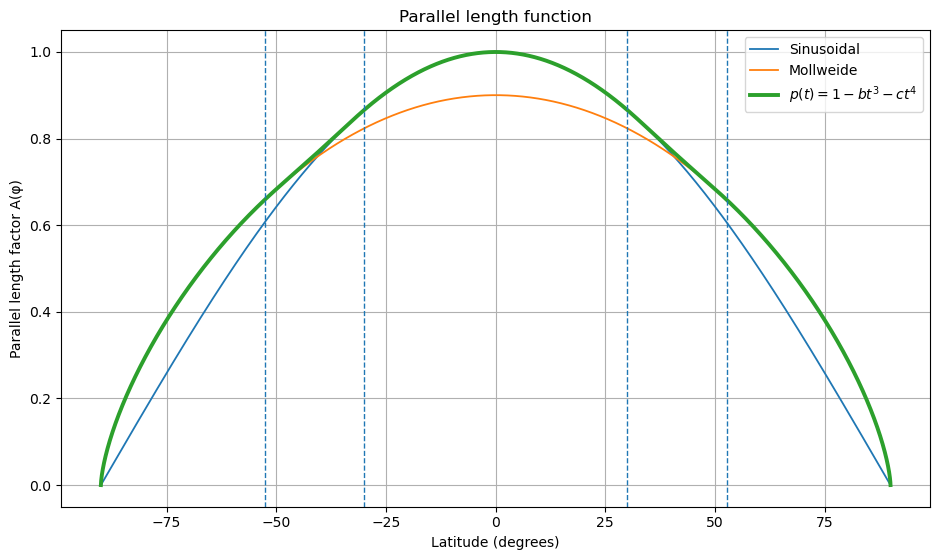

In [7]:
plot_parallel_lengths(
    phi1_deg=30,
    phi2_deg=52.6199754669689,
    b=2.2840341768984023,
    c=-2.5395240596949243,
)

In [8]:
import mpmath as mp
mp.mp.dps = 80

# -----------------------------
# Mollweide parallel spacing p(phi)
# -----------------------------

def theta_from_phi(phi):
    f = lambda th: 2*th + mp.sin(2*th) - mp.pi*mp.sin(phi)
    return mp.findroot(f, phi/2)

def p_moll(phi):
    th = theta_from_phi(phi)
    return mp.pi * mp.cos(phi) / (2 * mp.sqrt(2) * mp.cos(th))

def dp_moll(phi):
    return mp.diff(p_moll, phi, 1)

def ddp_moll(phi):
    return mp.diff(p_moll, phi, 2)

# C² Smooth Goode Homolopolynomial Projection: Cubic Version

In [10]:


# For p(t)=1-b t^3:
# P = 1 - bT^3
# Q = -3bT^2
# R = -6bT
#
# Eliminating a and T gives:
# R = -2 Q^2 / (3(1-P))
# Define residual:
def cubic_condition_residual(phi):
    P = p_moll(phi)
    Q = dp_moll(phi)
    R = ddp_moll(phi)
    return R + 2*Q**2/(3*(1-P))

# Search for sign changes over valid upper transition latitudes.
# Need P < 1 so that 1-P > 0; this is above the usual sinu-Mollweide crossing.
samples = []
for deg in [40 + i*0.1 for i in range(1, 500)]:  # 40.1 to 89.9
    phi = mp.radians(deg)
    try:
        res = cubic_condition_residual(phi)
        samples.append((phi, res))
    except Exception:
        pass

roots = []
for (a, fa), (b, fb) in zip(samples[:-1], samples[1:]):
    if fa == 0 or fa*fb < 0:
        try:
            r = mp.findroot(cubic_condition_residual, (a, b))
            if 0 < r < mp.pi/2 and all(abs(r-x) > mp.mpf("1e-30") for x in roots):
                roots.append(r)
        except Exception:
            pass

print("number of roots:", len(roots))

for phi2 in roots:
    P = p_moll(phi2)
    Q = dp_moll(phi2)
    R = ddp_moll(phi2)
    
    # From Q/R = T/2 for cubic
    T = 2*Q/R
    b = (1-P)/T**3
    phi1 = phi2 - T
    
    print("\nphi2 deg =", mp.degrees(phi2))
    print("P =", P)
    print("Q =", Q)
    print("R =", R)
    print("T rad =", T)
    print("T deg =", mp.degrees(T))
    print("phi1 deg =", mp.degrees(phi1))
    print("b =", b)
    print("check P =", 1 - a*T**3)
    print("check Q =", -3*a*T**2)
    print("check R =", -6*a*T)

# Also print residual min rough info for context
min_abs = min(samples, key=lambda x: abs(x[1]))
print("\nrough smallest residual sample:")
print("deg =", mp.degrees(min_abs[0]))
print("residual =", min_abs[1])


number of roots: 1

phi2 deg = 69.503234813475013115813279362420022248696972948054986709251606911548472254325347
P = 0.75545441279937775449749215375454046673477959130837992784047150379609827264662941
Q = -0.71557187078619960553491966258517544866073873670515012592464270044690765096102619
R = -1.3959036107799062951271444479837959184904334380968972476990439651471253376109533
T rad = 1.0252453898108364928623437158643468186358122029315315318613334824599158379904057
T deg = 58.742233801405823572557537882486582515012083696449880186537371840953688436306434
phi1 deg = 10.761001012069189543255741479933439733684889251605106522714235070594783818018913
b = 0.22692187071387503249181332501750904239101310937723364777688967677185812220834212
check P = -0.68902928470185782202595646971011647809191896870578661605487128015234848596653755
check Q = -4.9423171315507983001694255612203238105289789130633808862363545095345553744617246
check R = -9.64123746503787438865965761965683915714379641928211340490353005012

In [11]:
def p_spacing(phi):
    phi = np.asarray(phi, dtype=float)
    scalar_input = (phi.ndim == 0)

    u = np.abs(phi)
    out = np.empty_like(phi, dtype=float)

    mask_low = u <= phi1
    mask_mid = (u > phi1) & (u <= phi2)
    mask_high = u > phi2

    out[mask_low] = 1.0

    t = u[mask_mid] - phi1
    p_transition = 1.0
    if a is not None:
        p_transition -= a * t**2
    if b is not None:
        p_transition -= b * t**3
    if c is not None:
        p_transition -= c * t**4

    out[mask_mid] = p_transition

    if np.any(mask_high):
        out[mask_high] = np.array([float(p_moll(x)) for x in phi[mask_high]])

    return float(out) if scalar_input else out

In [12]:
type(30.0)

float

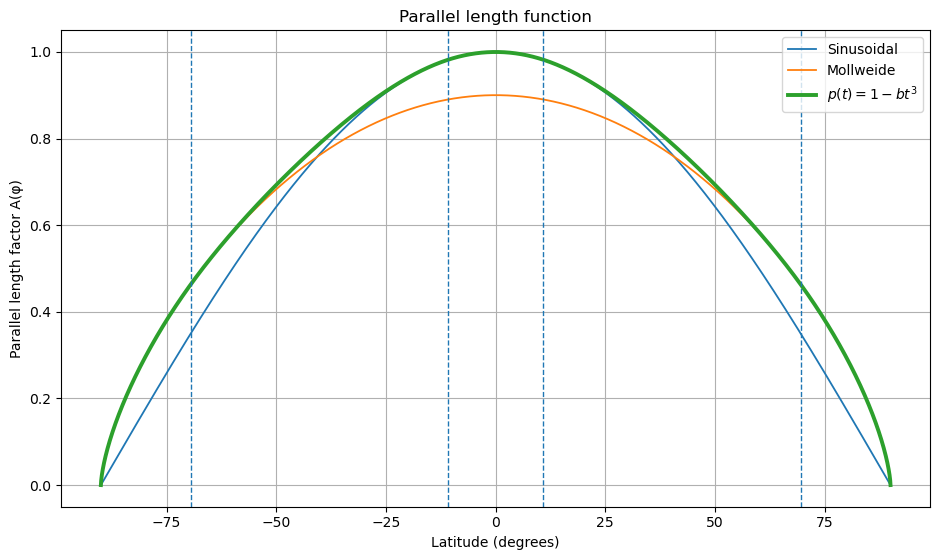

In [13]:
plot_parallel_lengths(
    phi1_deg=np.float64(float(mp.degrees(phi1))),
    phi2_deg=np.float64(float(mp.degrees(phi2))),
    b=np.float64(float(b)),
)

In [14]:
float(mp.degrees(phi1)),float(mp.degrees(phi2)),float(b)

(10.76100101206919, 69.50323481347502, 0.22692187071387504)

# C² Smooth Goode Homolopolynomial Projection: Quartic Version

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import PchipInterpolator
from scipy.integrate import cumulative_trapezoid
from matplotlib.collections import LineCollection


# -----------------------------
# 1. Mollweide parallel spacing and derivatives
# -----------------------------

def theta_from_phi(phi):
    phi = np.asarray(phi, dtype=float)
    theta = phi / 2

    for _ in range(70):
        f = 2*theta + np.sin(2*theta) - np.pi*np.sin(phi)
        fp = 2 + 2*np.cos(2*theta)
        theta = np.where(np.abs(fp) > 1e-12, theta - f/fp, theta)

    return theta

def p_moll(phi):
    phi = np.asarray(phi, dtype=float)
    th = theta_from_phi(phi)
    return np.pi*np.cos(phi) / (2*np.sqrt(2)*np.cos(th))

def derivs_p_moll(phi):
    phi = float(phi)
    h = 1e-5

    P = float(p_moll(phi))
    Q = float((p_moll(phi+h) - p_moll(phi-h)) / (2*h))
    R = float((p_moll(phi+h) - 2*p_moll(phi) + p_moll(phi-h)) / (h*h))

    return P, Q, R

# -----------------------------
# 2. Solve phi2 and quartic p(t)=1-b*t^3-c*t^4
#    Matching p, p', p'' to Mollweide at phi2
# -----------------------------

def bc_from(phi1, phi2):
    phi1 = float(phi1)
    phi2 = float(phi2)

    T = phi2 - phi1
    P, Q, R = derivs_p_moll(phi2)

    M = np.array(
        [
            [3*T*T, 4*T**3],
            [6*T,   12*T*T],
        ],
        dtype=float
    )

    rhs = np.array([-Q, -R], dtype=float)

    b, c = np.linalg.solve(M, rhs)
    return float(b), float(c)

def residual_phi2(phi2, phi1):
    phi1 = float(phi1)
    phi2 = float(phi2)

    T = phi2 - phi1
    if T <= 0:
        return np.nan

    P, Q, R = derivs_p_moll(phi2)
    b, c = bc_from(phi1, phi2)

    return 1 - b*T**3 - c*T**4 - P

def find_phi2(phi1):
    phi1 = float(phi1)
    start_deg = np.rad2deg(phi1) + 0.2

    xs = np.deg2rad(np.linspace(start_deg, 88.5, 700))
    vals = np.array([residual_phi2(x, phi1) for x in xs], dtype=float)

    for i in range(len(xs) - 1):
        if (
            np.isfinite(vals[i])
            and np.isfinite(vals[i+1])
            and vals[i] * vals[i+1] < 0
        ):
            return brentq(
                lambda z: residual_phi2(z, phi1),
                xs[i],
                xs[i+1],
                xtol=1e-13
            )

    raise RuntimeError("No phi2 root found")



In [17]:
# -----------------------------
# 0. Set lower transition latitude
# -----------------------------
phi1_deg = 30.0
phi1 = np.deg2rad(phi1_deg)

phi2 = find_phi2(phi1)
b, c = bc_from(phi1, phi2)

phi2_deg = np.rad2deg(phi2)

print(f"phi1 = {phi1_deg:.10f}°")
print(f"phi2 = {phi2_deg:.10f}°")
print(f"T = {phi2_deg - phi1_deg:.10f}°")
print(f"b = {b:.15g}")
print(f"c = {c:.15g}")
print(f"p(t) = 1 - ({b:.15g}) t^3 - ({c:.15g}) t^4, t in radians")

phi1 = 30.0000000000°
phi2 = 52.6199673713°
T = 22.6199673713°
b = 2.28403357067561
c = -2.53952290797257
p(t) = 1 - (2.28403357067561) t^3 - (-2.53952290797257) t^4, t in radians


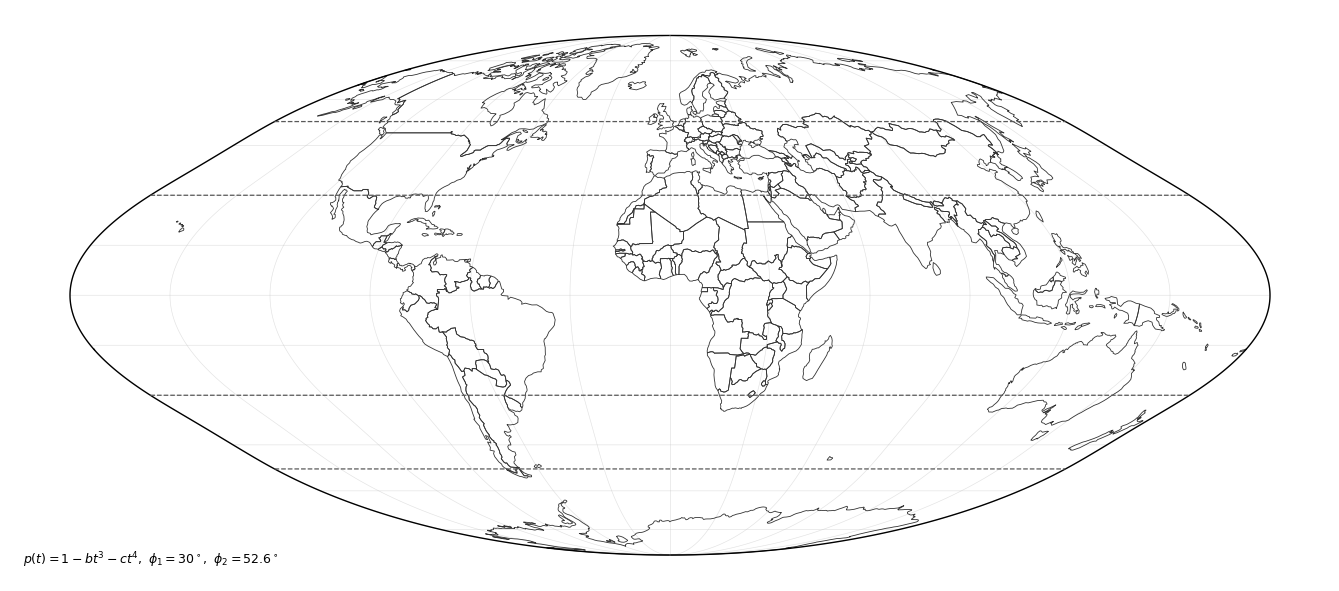

(<Figure size 1350x720 with 1 Axes>, <Axes: >)

In [18]:
plot_projection(
    phi1_deg=phi1_deg,
    phi2_deg=phi2_deg,
    b=b,
    c=c,
    display_mode="plain",
    show_caption=True,
    show_transition=True,
    save_path="/mnt/data/quartic_projection.png"
)

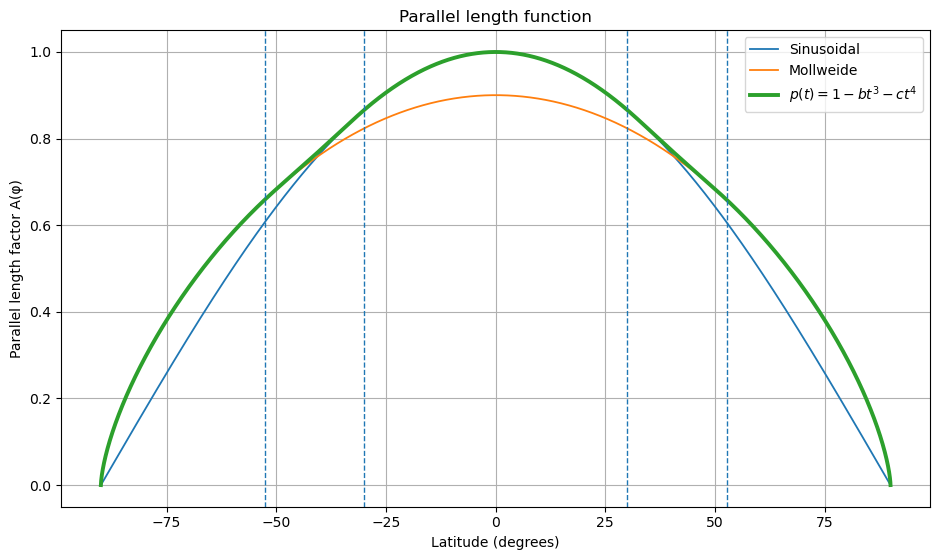

In [19]:
plot_parallel_lengths(
    phi1_deg=phi1_deg,
    phi2_deg=phi2_deg,
    b=b,
    c=c,
)

The cubic version is a degenerate quartic case (c = 0).

Because the projection was convex at φ₁ = 10.7610°, the concavity observed for larger φ₁ values is expected to disappear as φ₁ is lowered. Hence, there should exist a critical φ₁ below which the projection becomes convex again.

1. Test φ₁ = 30°.

   It looks like the transition curve becomes concave.

2. Find the minimum φ₁ at which the concavity disappears.

3. Select a suitably small φ₁ and generate a visually pleasing map.

The next task is to locate this threshold and identify visually pleasing convex maps with small φ₁. φ₁.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize_scalar
from scipy.interpolate import PchipInterpolator
from scipy.integrate import cumulative_trapezoid
from matplotlib.collections import LineCollection

def find_phi2(phi1):
    xs = np.deg2rad(np.linspace(np.rad2deg(phi1) + 0.2, 88.5, 500))
    vals = []

    for x in xs:
        try:
            vals.append(residual_phi2(x, phi1))
        except Exception:
            vals.append(np.nan)

    vals = np.array(vals, dtype=float)

    for i in range(len(xs) - 1):
        if (
            np.isfinite(vals[i])
            and np.isfinite(vals[i+1])
            and vals[i] * vals[i+1] < 0
        ):
            return brentq(
                lambda z: residual_phi2(z, phi1),
                xs[i],
                xs[i+1],
                xtol=1e-12
            )

    raise RuntimeError("no phi2")


def max_A2(phi1):
    phi2 = find_phi2(phi1)
    b, c = bc_from(phi1, phi2)

    def A(x):
        t = x - phi1
        return np.cos(x) / (1 - b*t**3 - c*t**4)

    def A2_num(x):
        h = 2e-4
        return (A(x+h) - 2*A(x) + A(x-h)) / (h*h)

    res = minimize_scalar(
        lambda z: -A2_num(z),
        bounds=(phi1 + 1e-5, phi2 - 1e-5),
        method="bounded",
        options={"xatol": 1e-10}
    )

    return -res.fun, res.x, phi2, b, c


def boundary_residual(phi1):
    return max_A2(phi1)[0]


# Find boundary phi1 where max A'' = 0
lo, hi = np.deg2rad(25), np.deg2rad(30)

xs = np.deg2rad(np.linspace(25, 30, 26))

prev_x = xs[0]
prev_v = boundary_residual(prev_x)
bracket = None

for x in xs[1:]:
    v = boundary_residual(x)

    if prev_v * v < 0:
        bracket = (prev_x, x)
        break

    prev_x, prev_v = x, v

if bracket is None:
    raise RuntimeError("No bracket found for phi1 boundary")

phi1_star = brentq(
    lambda z: boundary_residual(z),
    bracket[0],
    bracket[1],
    xtol=1e-10
)

mx, touch, phi2_star, b_star, c_star = max_A2(phi1_star)

print("phi1* deg =", np.rad2deg(phi1_star))
print("phi2* deg =", np.rad2deg(phi2_star))
print("touch latitude deg =", np.rad2deg(touch))
print("max A'' ≈", mx)
print("b =", b_star)
print("c =", c_star)
print("p(t)=1-b t^3-c t^4, t in radians")

phi1* deg = 27.06352394572084
phi2* deg = 56.19996268319175
touch latitude deg = 41.12826436983312
max A'' ≈ -1.4432899320127035e-07
b = 1.400063800841254
c = -1.1402938341030764
p(t)=1-b t^3-c t^4, t in radians


In [22]:
np.rad2deg(phi1_star),np.rad2deg(phi2_star),np.rad2deg(touch),b_star,c_star



(27.06352394572084,
 56.19996268319175,
 41.12826436983312,
 1.400063800841254,
 -1.1402938341030764)

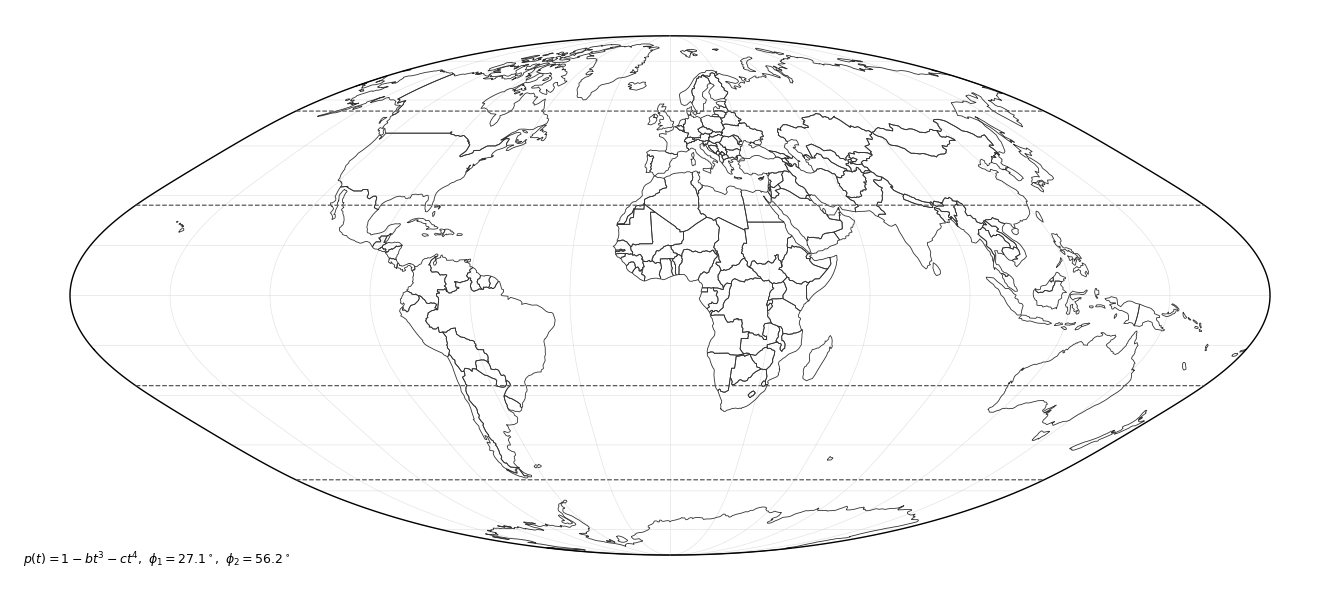

(<Figure size 1350x720 with 1 Axes>, <Axes: >)

In [23]:
# Quartic Transition Version
plot_projection(
    phi1_deg=np.rad2deg(phi1_star),
    phi2_deg=np.rad2deg(phi2_star),
    b=b_star,
    c=c_star,
    display_mode="plain",
    show_caption=True,
    show_transition=True,
    save_path="/mnt/data/quartic_touch_projection.png"
)

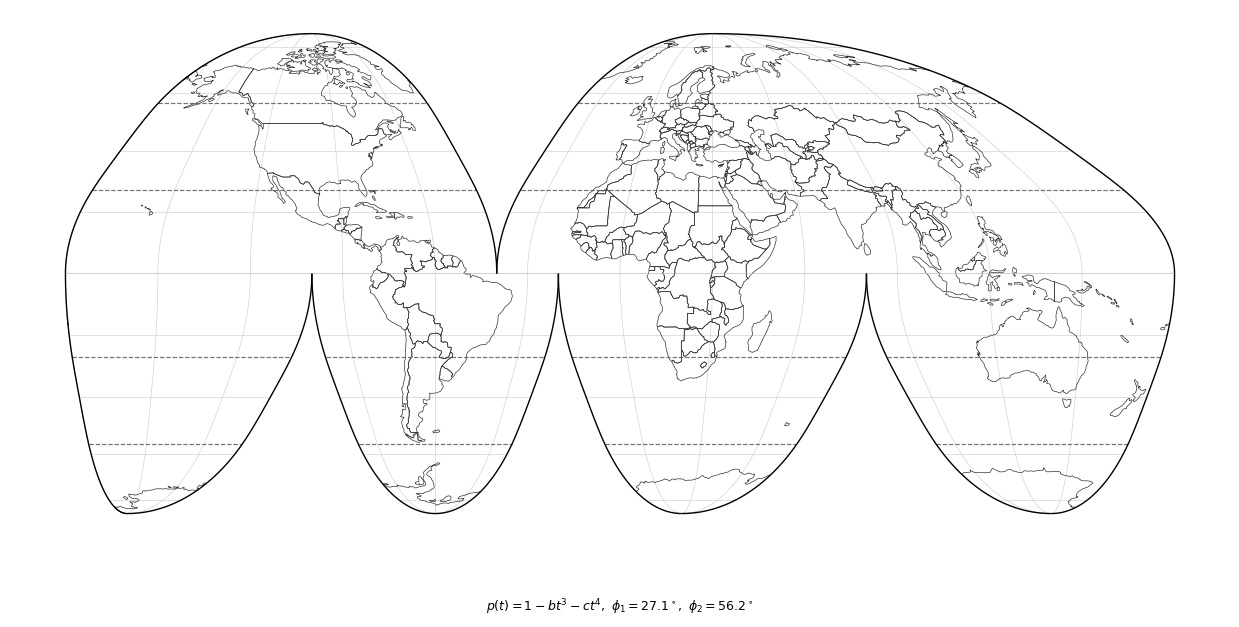

(<Figure size 1250x680 with 1 Axes>, <Axes: >)

In [24]:
# Quartic Transition Version
plot_projection_interrupted(
    phi1_deg=np.rad2deg(phi1_star),
    phi2_deg=np.rad2deg(phi2_star),
    b=b_star,
    c=c_star,
    display_mode="plain",
    show_caption=True,
    show_transition=True,
    save_path="/mnt/data/quartic_touch_projection.png"
)

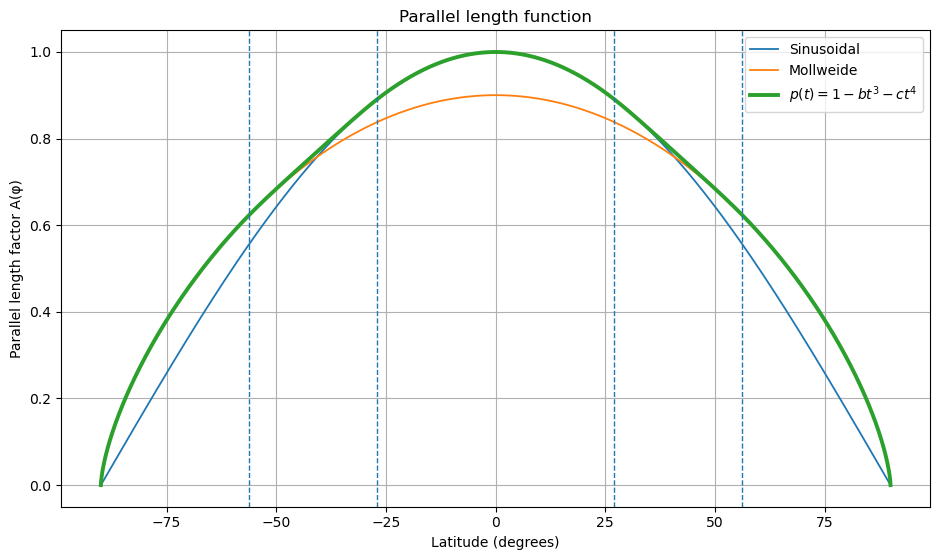

In [25]:
plot_parallel_lengths(
    phi1_deg=np.rad2deg(phi1_star),
    phi2_deg=np.rad2deg(phi2_star),
    b=b_star,
    c=c_star,
)

In [26]:
# -----------------------------
# 0. Set lower transition latitude as axial tilt(Tropic of Cancer latitude)

# Mean obliquity of the ecliptic, IAU/Meeus polynomial, for 2026-05-28.
# epsilon = 23°26'21.448" - 46.8150"T - 0.00059"T^2 + 0.001813*T^3
# T = Julian centuries from J2000.0
# -----------------------------

def julian_day(year, month, day):
    if month <= 2:
        year -= 1
        month += 12
    A = year // 100
    B = 2 - A + A // 4
    return int(365.25*(year + 4716)) + int(30.6001*(month + 1)) + day + B - 1524.5

JD = julian_day(2026, 5, 28)
T_cent = (JD - 2451545.0) / 36525.0
eps_arcsec = 23*3600 + 26*60 + 21.448 - 46.8150*T_cent - 0.00059*T_cent**2 + 0.001813*T_cent**3
tropic_deg = eps_arcsec / 3600

# Use phi1 as Tropic of Cancer
phi1_deg = tropic_deg
phi1 = np.deg2rad(phi1_deg)


phi2 = find_phi2(phi1)
b, c = bc_from(phi1, phi2)

phi2_deg = np.rad2deg(phi2)

print(f"phi1 = {phi1_deg:.10f}°")
print(f"phi2 = {phi2_deg:.10f}°")
print(f"T = {phi2_deg - phi1_deg:.10f}°")
print(f"b = {b:.15g}")
print(f"c = {c:.15g}")
print(f"p(t) = 1 - ({b:.15g}) t^3 - ({c:.15g}) t^4, t in radians")

phi1 = 23.4358576885°
phi2 = 60.5307803820°
T = 37.0949226935°
b = 0.861062287656096
c = -0.494315180311629
p(t) = 1 - (0.861062287656096) t^3 - (-0.494315180311629) t^4, t in radians


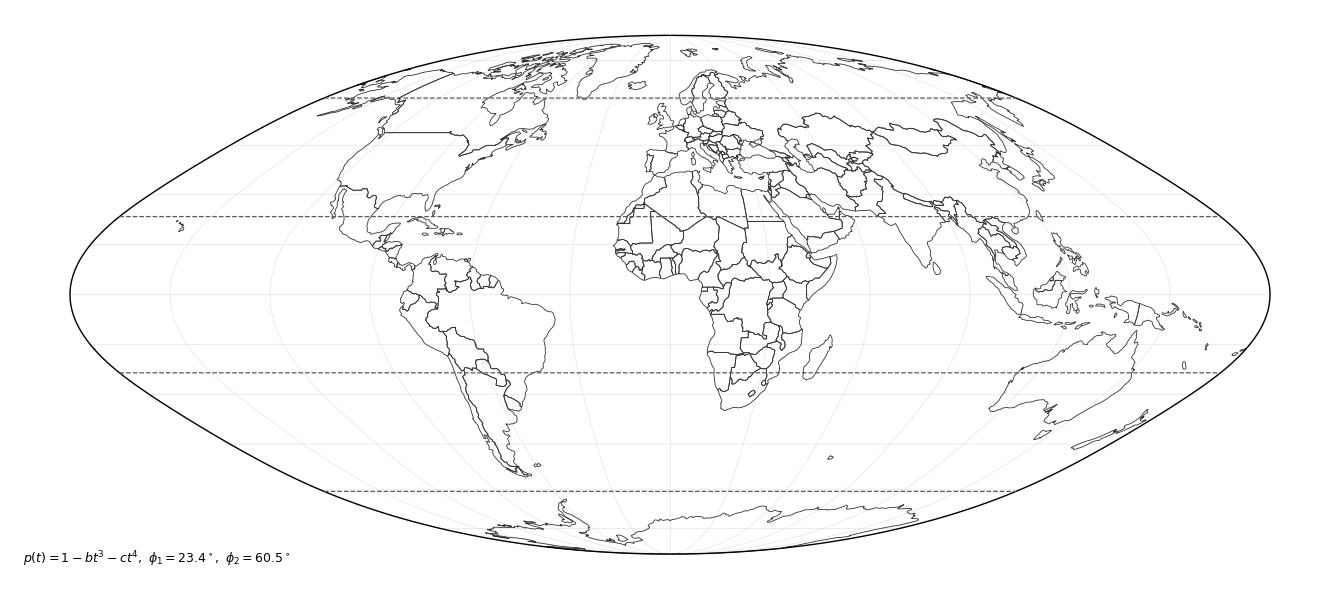

(<Figure size 1350x720 with 1 Axes>, <Axes: >)

In [27]:
plot_projection(
    phi1_deg=phi1_deg,
    phi2_deg=phi2_deg,
    b=b,
    c=c,
    display_mode="plain",
    show_caption=True,
    show_transition=True,
    save_path="/mnt/data/quartic_tilt_projection.png"
)

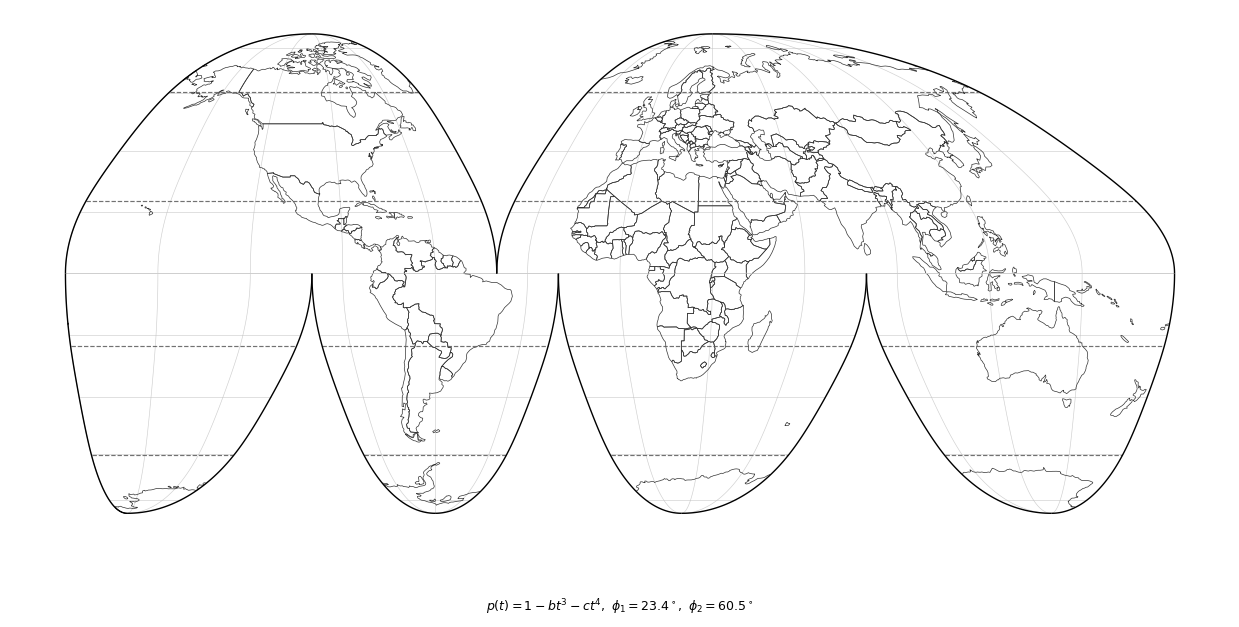

(<Figure size 1250x680 with 1 Axes>, <Axes: >)

In [28]:
plot_projection_interrupted(
    phi1_deg=phi1_deg,
    phi2_deg=phi2_deg,
    b=b,
    c=c,
    display_mode="plain",
    show_caption=True,
    show_transition=True,
    save_path="/mnt/data/quartic_tilt_projection.png"
)

# C¹ Smooth Goode Homolopolynomial Projection: Square Version

bracket deg: (63.13779632721202, 63.21836393989984)
critical upper phi2 deg = 63.143823416694154
critical lower phi1 deg = 29.474562346292576
transition width T deg = 33.66926107040158
a = 0.500000063837869
touch latitude deg = 29.4745690311409
max A'' = 0.0
p(t)=1-a t^2; t in radians
sample A'' min/max: -0.8656504972277617 -9.634879680701657e-05


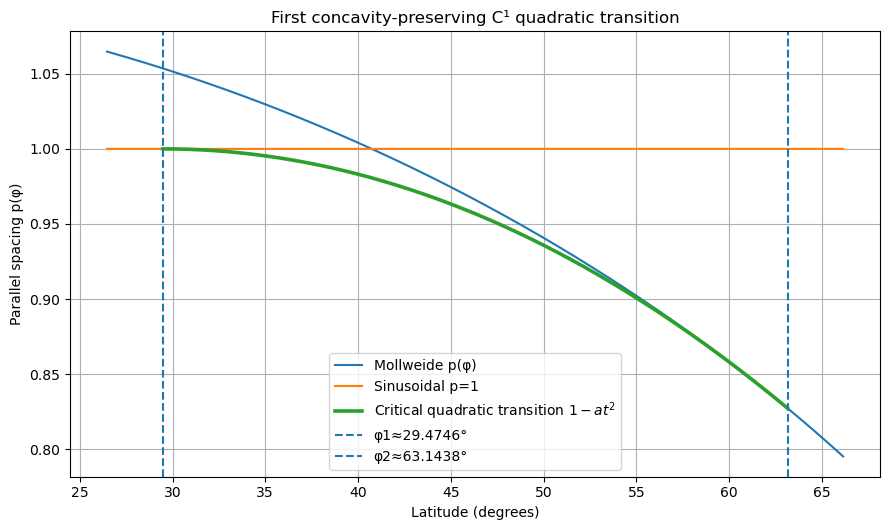

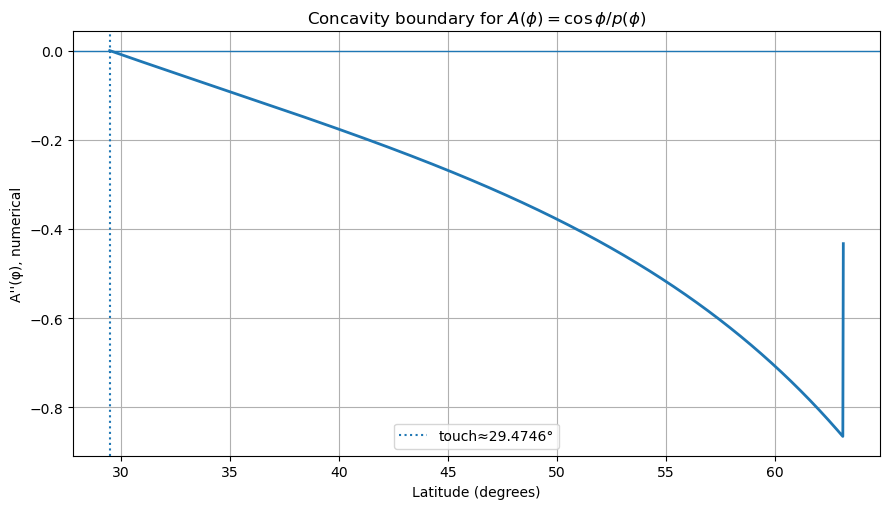

('/mnt/data/critical_quadratic_c1_spacing.png',
 '/mnt/data/critical_quadratic_c1_A_second_derivative.png')

In [30]:

# -----------------------------
# Mollweide parallel spacing p(phi)
# -----------------------------
def theta_from_phi(phi):
    phi = np.asarray(phi, dtype=float)
    theta = phi / 2
    for _ in range(80):
        f = 2*theta + np.sin(2*theta) - np.pi*np.sin(phi)
        fp = 2 + 2*np.cos(2*theta)
        theta = np.where(np.abs(fp) > 1e-13, theta - f/fp, theta)
    return theta

def p_moll(phi):
    th = theta_from_phi(phi)
    return np.pi*np.cos(phi)/(2*np.sqrt(2)*np.cos(th))

def dp_moll(phi):
    h = 1e-6
    return (p_moll(phi+h) - p_moll(phi-h))/(2*h)
# -----------------------------
# Quadratic C1 family:
# p(t)=1-a t^2, t=phi-phi1
# At phi2, P=pM(phi2), Q=pM'(phi2)
# T=-2(1-P)/Q, phi1=phi2-T, a=(1-P)/T^2
# -----------------------------
def quadratic_params_from_phi2(phi2):
    P = float(p_moll(phi2))
    Q = float(dp_moll(phi2))
    T = -2*(1-P)/Q
    phi1 = phi2 - T
    a = (1-P)/T**2
    return phi1, phi2, T, a, P, Q

def A2_max_for_phi2(phi2):
    phi1, phi2, T, a, P, Q = quadratic_params_from_phi2(phi2)
    if not (0 < phi1 < phi2 < np.pi/2 and a > 0 and T > 0):
        return np.nan, None
    
    def A(x):
        t = x - phi1
        return np.cos(x)/(1 - a*t*t)
    
    def A2(x):
        h = 1e-4
        return (A(x+h) - 2*A(x) + A(x-h))/(h*h)
    
    res = minimize_scalar(lambda z: -A2(z), bounds=(phi1 + 1e-7, phi2 - 1e-7), method="bounded",
                          options={"xatol": 1e-12})
    return -res.fun, (phi1, phi2, T, a, res.x)

# Scan phi2 and find where max A'' crosses 0
deg_grid = np.linspace(40.74, 89.0, 600)
vals = []
params = []
for deg in deg_grid:
    phi2 = np.deg2rad(deg)
    try:
        m, par = A2_max_for_phi2(phi2)
    except Exception:
        m, par = np.nan, None
    vals.append(m); params.append(par)
vals = np.array(vals)

# Find crossing from positive to non-positive
bracket = None
for i in range(len(deg_grid)-1):
    if np.isfinite(vals[i]) and np.isfinite(vals[i+1]):
        if vals[i] > 0 and vals[i+1] <= 0:
            bracket = (np.deg2rad(deg_grid[i]), np.deg2rad(deg_grid[i+1]))
            break

print("bracket deg:", None if bracket is None else (np.rad2deg(bracket[0]), np.rad2deg(bracket[1])))

root_phi2 = brentq(lambda x: A2_max_for_phi2(x)[0], bracket[0], bracket[1], xtol=1e-11)
maxA2, par = A2_max_for_phi2(root_phi2)
phi1, phi2, T, a, touch = par

print("critical upper phi2 deg =", np.rad2deg(phi2))
print("critical lower phi1 deg =", np.rad2deg(phi1))
print("transition width T deg =", np.rad2deg(T))
print("a =", a)
print("touch latitude deg =", np.rad2deg(touch))
print("max A'' =", maxA2)
print("p(t)=1-a t^2; t in radians")

# Check sample A'' min/max across interval
xs = np.linspace(phi1, phi2, 3000)
def A_quad(x):
    t = x - phi1
    return np.cos(x)/(1-a*t*t)
A = A_quad(xs)
A2_arr = np.gradient(np.gradient(A, xs), xs)
print("sample A'' min/max:", A2_arr.min(), A2_arr.max())

# Plot p and A''
lat_deg = np.linspace(np.rad2deg(phi1)-3, np.rad2deg(phi2)+3, 2000)
ph = np.deg2rad(lat_deg)
p_quad = np.full_like(ph, np.nan, dtype=float)
mask = (ph >= phi1) & (ph <= phi2)
p_quad[mask] = 1 - a*(ph[mask]-phi1)**2

plt.figure(figsize=(9,5.4))
plt.plot(lat_deg, p_moll(ph), label="Mollweide p(φ)")
plt.plot(lat_deg, np.ones_like(ph), label="Sinusoidal p=1")
plt.plot(lat_deg, p_quad, linewidth=2.6, label=r"Critical quadratic transition $1-at^2$")
plt.axvline(np.rad2deg(phi1), linestyle="--", label=f"φ1≈{np.rad2deg(phi1):.4f}°")
plt.axvline(np.rad2deg(phi2), linestyle="--", label=f"φ2≈{np.rad2deg(phi2):.4f}°")
plt.xlabel("Latitude (degrees)")
plt.ylabel("Parallel spacing p(φ)")
plt.title("First concavity-preserving C¹ quadratic transition")
plt.grid(True)
plt.legend()
plt.tight_layout()
p_path = "/mnt/data/critical_quadratic_c1_spacing.png"
plt.savefig(p_path, dpi=220)
plt.show()

plt.figure(figsize=(9,5.2))
plt.plot(np.rad2deg(xs), A2_arr, linewidth=2)
plt.axhline(0, linewidth=1)
plt.axvline(np.rad2deg(touch), linestyle=":", label=f"touch≈{np.rad2deg(touch):.4f}°")
plt.xlabel("Latitude (degrees)")
plt.ylabel("A''(φ), numerical")
plt.title(r"Concavity boundary for $A(\phi)=\cos\phi/p(\phi)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
a2_path = "/mnt/data/critical_quadratic_c1_A_second_derivative.png"
plt.savefig(a2_path, dpi=220)
plt.show()

p_path, a2_path


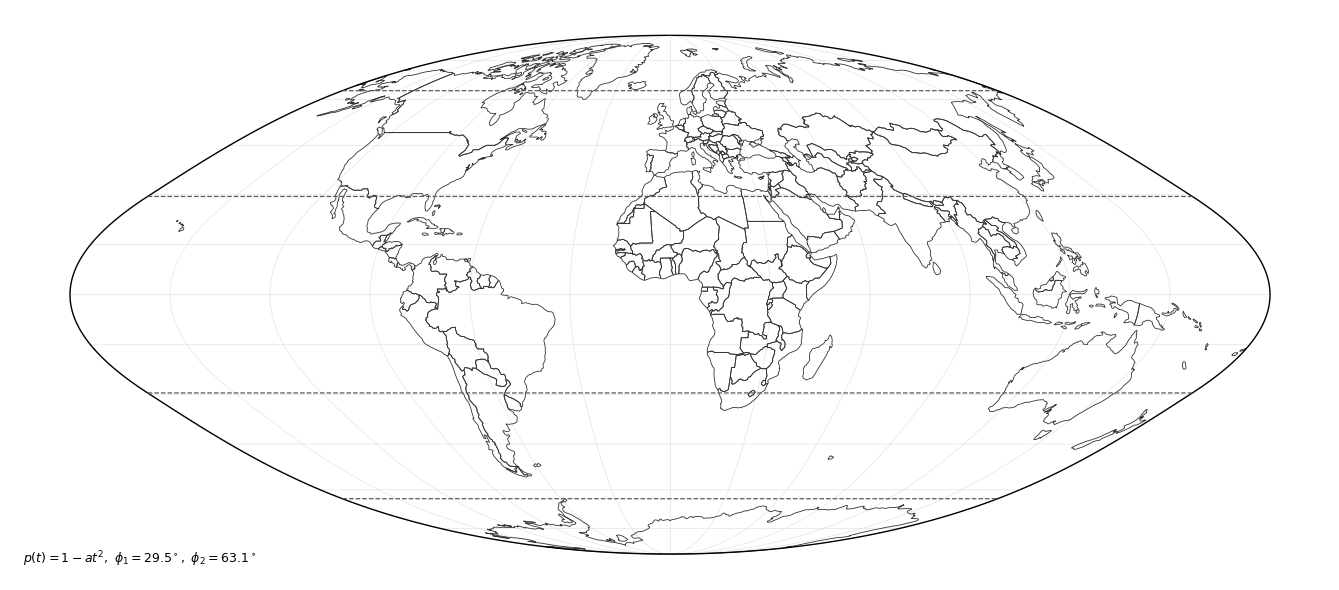

(<Figure size 1350x720 with 1 Axes>, <Axes: >)

In [31]:
plot_projection(
    phi1_deg=np.rad2deg(phi1),
    phi2_deg=np.rad2deg(phi2),
    a=a,
    display_mode="plain",
    show_caption=True,
    show_transition=True,
    save_path="/mnt/data/c1_goode_homolopolynomial_projection.png"
)

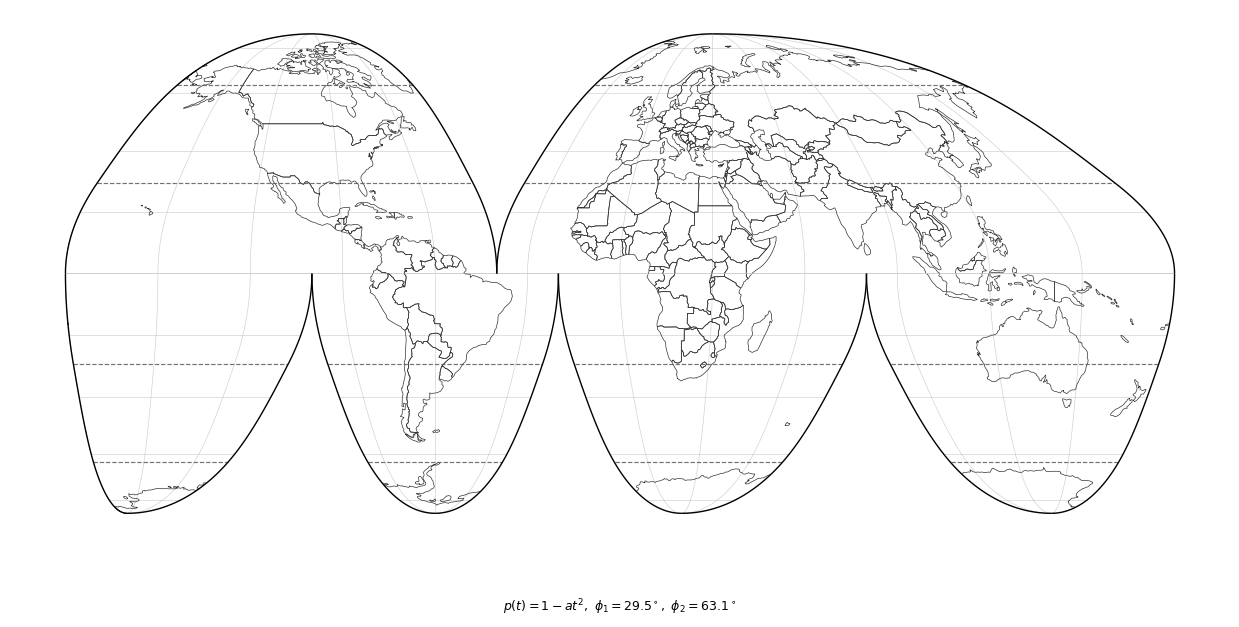

(<Figure size 1250x680 with 1 Axes>, <Axes: >)

In [32]:
plot_projection_interrupted(
    phi1_deg=np.rad2deg(phi1),
    phi2_deg=np.rad2deg(phi2),
    a=a,
    display_mode="plain",
    show_caption=True,
    show_transition=True,
    save_path="/mnt/data/c1_goode_homolopolynomial_projection.png"
)

## Conclusion

This study demonstrates that the mid-latitude transition region of the Goode Homolosine projection can be replaced by Strebe-style equal-area polynomial projections while maintaining smooth junctions with the Sinusoidal and Mollweide components.

By expressing the parallel spacing function as a polynomial in latitude and matching it to the Sinusoidal and Mollweide projections, we obtained equal-area projections whose map boundaries satisfy \(C^n\) continuity conditions. Furthermore, admissible parameter ranges were identified in which the boundary retains the desired concavity properties.

These results demonstrate that smooth Homolosine-type projections can be constructed systematically through polynomial control of the parallel-spacing density, yielding projections that are both geometrically well-behaved and visually appealing.